# Notebook 01: Donor Churn Classifier

## Section 1 - Problem Framing

**Business Problem:** Predict which donors are at risk of lapsing so the fundraising team can intervene before they stop giving entirely. Harbor of Hope relies on donations to continue operating, so donor retention is a top priority.

**Approach:** Predictive binary classification. We label supporters as "churned" if they have not made a monetary donation in the last 365 days and "retained" otherwise. A one-year threshold is appropriate here because many donors give on an annual cycle — often around the holidays — and labeling someone churned after only a few months would misclassify seasonal givers as lost donors.

**Goal: Prediction, not explanation.** The goal is to identify at-risk donors accurately enough to act on. Out-of-sample predictive performance matters more than coefficient interpretability. We will not treat model outputs as causal evidence.

**Success Metric:** F1 score — this balances precision (not wasting outreach resources on donors who were never at risk) and recall (not missing truly at-risk donors). F1 is more informative than raw accuracy when classes are imbalanced, which we expect given that not all supporters donate regularly.

**Stakeholders:** Fundraising team, case managers, executive leadership.

## Section 2 - Data Acquisition, Preparation & Exploration

In [2]:

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load data
supporters = pd.read_csv("../backend/HarborOfHope.API/Data/lighthouse_csv_v7/supporters.csv")
donations = pd.read_csv("../backend/HarborOfHope.API/Data/lighthouse_csv_v7/donations.csv")

print(f"Supporters: {len(supporters)} rows")
print(f"Donations: {len(donations)} rows")
print(f"Donation types: {donations['donation_type'].value_counts().to_dict()}")

Supporters: 60 rows
Donations: 420 rows
Donation types: {'Monetary': 234, 'InKind': 98, 'Time': 46, 'SocialMedia': 23, 'Skills': 19}


### Raw Data Exploration

Before any transformation, we inspect both tables for shape, data types, missing values, and basic distributions. This documents what the data actually looks like and informs every preparation decision that follows.

In [3]:
# --- Supporters table ---
print("=== Supporters ===")
print(f"Shape: {supporters.shape}")
print(f"\nData types:\n{supporters.dtypes}")
print(f"\nMissing values:\n{supporters.isnull().sum()}")
print(f"\nsupporter_type:\n{supporters['supporter_type'].value_counts()}")
print(f"\nacquisition_channel:\n{supporters['acquisition_channel'].value_counts()}")
print(f"\nregion:\n{supporters['region'].value_counts()}")
print(f"\nstatus:\n{supporters['status'].value_counts()}")

=== Supporters ===
Shape: (60, 15)

Data types:
supporter_id            int64
supporter_type         object
display_name           object
organization_name      object
first_name             object
last_name              object
relationship_type      object
region                 object
country                object
email                  object
phone                  object
status                 object
created_at             object
first_donation_date    object
acquisition_channel    object
dtype: object

Missing values:
supporter_id            0
supporter_type          0
display_name            0
organization_name      56
first_name              4
last_name               4
relationship_type       0
region                  0
country                 0
email                   0
phone                   0
status                  0
created_at              0
first_donation_date     1
acquisition_channel     0
dtype: int64

supporter_type:
supporter_type
MonetaryDonor          17
InKindDono

In [4]:
# --- Donations table ---
print("=== Donations ===")
print(f"Shape: {donations.shape}")
print(f"\nMissing values:\n{donations.isnull().sum()}")
print(f"\nDonation types:\n{donations['donation_type'].value_counts()}")

monetary_raw = donations[donations['donation_type'] == 'Monetary'].copy()
monetary_raw['donation_date'] = pd.to_datetime(monetary_raw['donation_date'])
print(f"\nMonetary donation amount stats:\n{monetary_raw['amount'].describe()}")
print(f"\nDate range: {monetary_raw['donation_date'].min().date()} to {monetary_raw['donation_date'].max().date()}")

# Join integrity: how many supporters have at least one monetary donation?
donors_with_monetary = monetary_raw['supporter_id'].nunique()
print(f"\nSupporters with monetary donations: {donors_with_monetary} of {len(supporters)}")
print(f"Supporters with NO monetary donations: {len(supporters) - donors_with_monetary}")

=== Donations ===
Shape: (420, 13)

Missing values:
donation_id           0
supporter_id          0
donation_type         0
donation_date         0
is_recurring          0
campaign_name       275
channel_source        0
currency_code       186
amount              186
estimated_value       0
impact_unit           0
notes                 0
referral_post_id    343
dtype: int64

Donation types:
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64

Monetary donation amount stats:
count     234.00000
mean     1028.73735
std       767.59608
min       250.00000
25%       482.50750
50%       819.63000
75%      1333.15500
max      6481.54000
Name: amount, dtype: float64

Date range: 2023-01-13 to 2026-03-01

Supporters with monetary donations: 57 of 60
Supporters with NO monetary donations: 3


### Data Preparation & Feature Engineering

With the raw data understood, we now filter to monetary donations, compute RFM-style features per supporter, and define the churn label.

**Why monetary only?** In-kind, time, and social media contributions do not reflect the financial retention we are trying to predict.

**Churn definition:** A supporter is labeled churned if their last monetary donation was more than 365 days ago. This aligns with annual giving cycles common in nonprofit fundraising.

In [5]:
# Filter to monetary donations only
monetary = donations[donations['donation_type'] == 'Monetary'].copy()

# Change to date types
monetary['donation_date'] = pd.to_datetime(monetary['donation_date'])

print(f"Monetary donations: {len(monetary)} rows")

# Reference date: use today so recency values stay current each time the notebook is run
reference_date = pd.Timestamp.today().normalize()
print(f"Reference date (today): {reference_date.date()}")

Monetary donations: 234 rows
Reference date (today): 2026-04-09


In [6]:
# Sort by date so last() gives the most recent donation
monetary_sorted = monetary.sort_values("donation_date")

# Engineer features per supporter
# recency is computed here only to define the churn label -- it is NOT used as a training feature
rfm = monetary_sorted.groupby("supporter_id").agg(
    recency=("donation_date", lambda x: (reference_date - x.max()).days),
    frequency=("donation_id", "count"),
    monetary_avg=("amount", "mean"),
    last_donation_amount=("amount", "last"),
    first_donation=("donation_date", "min")
).reset_index()

# Tenure: days from first donation to today
rfm["tenure_days"] = (reference_date - rfm["first_donation"]).dt.days

# Average days between donations
# For donors with only one donation, use tenure_days as a conservative estimate
rfm["avg_days_between"] = rfm.apply(
    lambda r: r["tenure_days"] / (r["frequency"] - 1) if r["frequency"] > 1 else r["tenure_days"],
    axis=1
)

rfm.drop(columns=["first_donation"], inplace=True)

print("Features engineered for", len(rfm), "supporters")
rfm.head()

Features engineered for 57 supporters


,supporter_id,recency,frequency,monetary_avg,last_donation_amount,tenure_days,avg_days_between
0,1,49,7,1081.138571,689.85,1111,185.166667
1,2,976,2,1740.040000,915.05,1128,1128.000000
2,3,208,9,1025.078889,527.51,1142,142.750000
3,4,39,8,1086.841250,342.96,884,126.285714
4,5,189,4,1184.645000,504.86,841,280.333333


In [7]:
# Merge with supporter demographics
df = rfm.merge(supporters[["supporter_id", "supporter_type", "acquisition_channel", "region"]],
               on="supporter_id", how="left")

# Create binary target: churned if no donation in the last 365 days (annual giving cycle)
df["churned"] = (df["recency"] > 365).astype(int)

print("Dataset shape:", df.shape)
print("Target distribution:")
print(df["churned"].value_counts())
print("" \
"Churn rate:", round(df["churned"].mean() * 100, 2), "%")
df.head()

Dataset shape: (57, 11)
Target distribution:
churned
0    38
1    19
Name: count, dtype: int64
Churn rate: 33.33 %


,supporter_id,recency,frequency,monetary_avg,last_donation_amount,tenure_days,avg_days_between,supporter_type,acquisition_channel,region,churned
0,1,49,7,1081.138571,689.85,1111,185.166667,SocialMediaAdvocate,SocialMedia,Luzon,0
1,2,976,2,1740.040000,915.05,1128,1128.000000,Volunteer,SocialMedia,Mindanao,1
2,3,208,9,1025.078889,527.51,1142,142.750000,MonetaryDonor,SocialMedia,Luzon,0
3,4,39,8,1086.841250,342.96,884,126.285714,MonetaryDonor,Church,Mindanao,0
4,5,189,4,1184.645000,504.86,841,280.333333,InKindDonor,Website,Mindanao,0


### Univariate Feature Analysis

Before modeling we examine each feature independently to understand its distribution, check for outliers, and confirm it carries signal relative to the churn label. Observations here directly inform feature engineering and model choices.

**Numeric features in the model:**
- `frequency` — total number of monetary donations. More frequent donors are expected to be more retained.
- `monetary_avg` — average gift size. May distinguish committed donors from casual or one-time givers.
- `last_donation_amount` — amount of the most recent donation. A declining final gift could signal disengagement.
- `tenure_days` — days since first donation. Longer-tenured donors may have stronger loyalty to the organization.
- `avg_days_between` — average days between donations. Contextualizes absence: a donor at 300 days is high-risk if they normally give every 60 days, but unremarkable if they give annually.

**Categorical features:**
- `supporter_type` — role of the supporter (MonetaryDonor, Volunteer, etc.). Different types may have structurally different churn rates.
- `acquisition_channel` — how the donor was acquired. Channel may correlate with long-term engagement quality.
- `region` — geographic region. May reflect socioeconomic or cultural patterns in giving behavior.

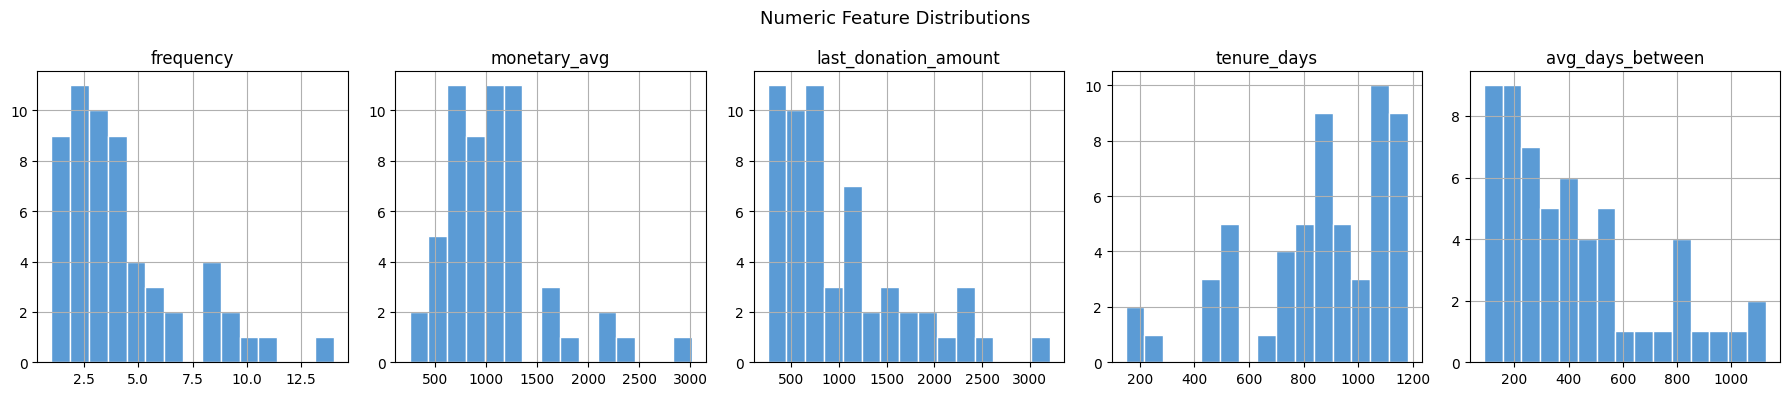

In [8]:
# Numeric features: histograms
numeric_features_plot = ["frequency", "monetary_avg", "last_donation_amount", "tenure_days", "avg_days_between"]

fig, axes = plt.subplots(1, len(numeric_features_plot), figsize=(18, 4))
for ax, col in zip(axes, numeric_features_plot):
    df[col].hist(bins=15, ax=ax, color="#5B9BD5", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Numeric Feature Distributions", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Outlier analysis using IQR method
# Tree-based models are robust to outliers, but LR with StandardScaler is not.
# We document any extreme values here so modeling choices can account for them.
numeric_features_plot = ['frequency', 'monetary_avg', 'last_donation_amount', 'tenure_days', 'avg_days_between']

print("Outlier Analysis (IQR method: values beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR)")
print("=" * 75)
for col in numeric_features_plot:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    flag = ' <-- outliers present' if len(outliers) > 0 else ''
    print(f"  {col:<25} bounds=[{lower:7.1f}, {upper:8.1f}]  outliers: {len(outliers)}{flag}")

print()
print("Note: The preprocessing pipeline uses StandardScaler for numeric features.")
print("Extreme outliers can distort scaling for Logistic Regression.")
print("Tree-based models (RandomForest, GradientBoosting) are unaffected by outliers.")


Outlier Analysis (IQR method: values beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR)
  frequency                 bounds=[   -2.5,      9.5]  outliers: 3 <-- outliers present
  monetary_avg              bounds=[ -119.6,   2079.8]  outliers: 4 <-- outliers present
  last_donation_amount      bounds=[ -699.0,   2571.6]  outliers: 1 <-- outliers present
  tenure_days               bounds=[  277.5,   1545.5]  outliers: 3 <-- outliers present
  avg_days_between          bounds=[ -335.7,   1035.0]  outliers: 3 <-- outliers present

Note: The preprocessing pipeline uses StandardScaler for numeric features.
Extreme outliers can distort scaling for Logistic Regression.
Tree-based models (RandomForest, GradientBoosting) are unaffected by outliers.


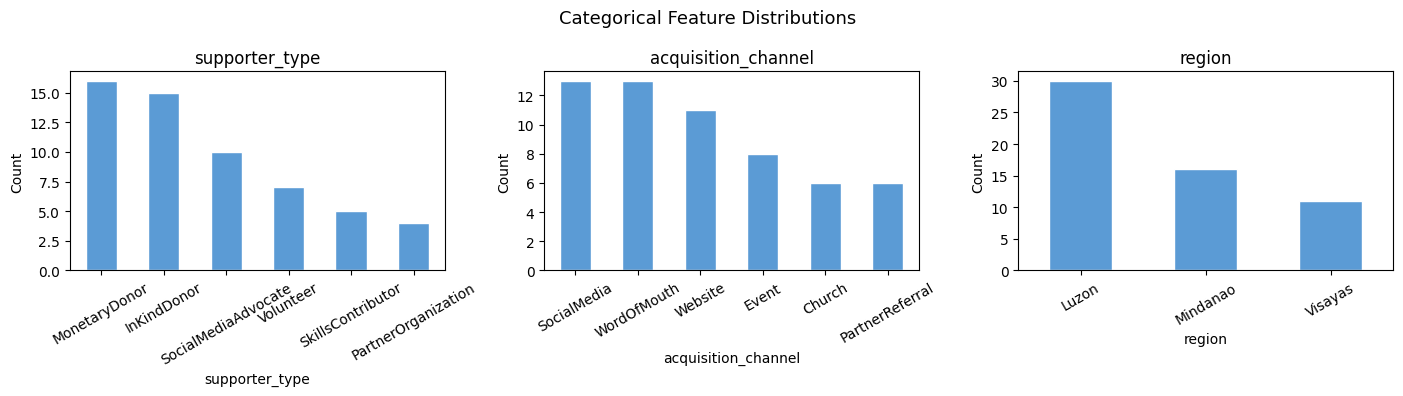

In [10]:
# Categorical features: bar charts of value counts
cat_features_plot = ["supporter_type", "acquisition_channel", "region"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_features_plot):
    df[col].value_counts().plot(kind="bar", ax=ax, color="#5B9BD5", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Categorical Feature Distributions", fontsize=13)
plt.tight_layout()
plt.show()

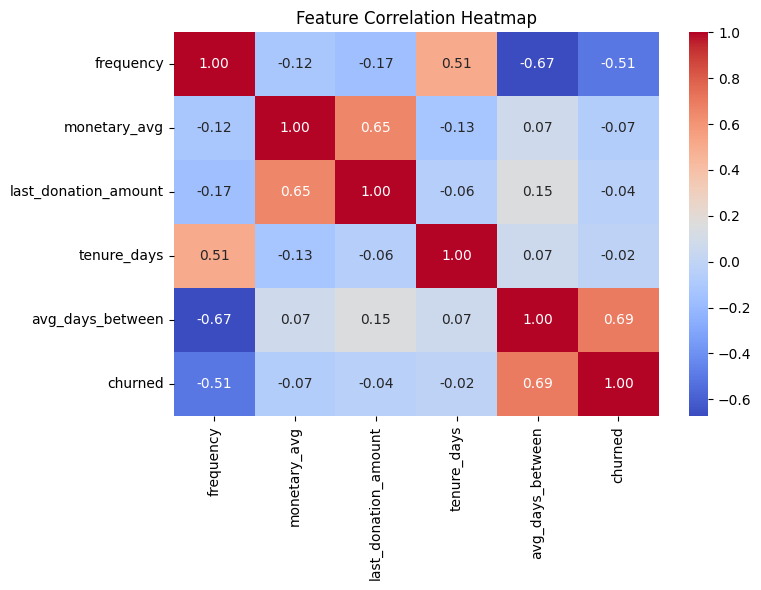

In [11]:
# Correlation heatmap of numeric features vs churn label
numeric_for_corr = ["frequency", "monetary_avg", "last_donation_amount", "tenure_days", "avg_days_between"]
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numeric_for_corr + ["churned"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Exploration Findings

*(Update this narrative after running the cells above with actual observed values.)*

**Numeric features:**
- **Frequency** — retained donors tend to have higher donation counts. Low-frequency donors (1-2 donations) are overrepresented in the churned group, suggesting that donors who never established a giving habit are most at risk.
- **Monetary avg** — gift size alone is likely a weak separator. High-value donors churn too, meaning the organization cannot rely on amount as a proxy for loyalty.
- **Last donation amount** — compare medians between groups. A lower last gift among churned donors would support the idea that declining amounts precede disengagement.
- **Tenure days** — longer-tenured donors may churn less, but interpret carefully alongside frequency. A long-tenured, low-frequency donor is still at risk.
- **Avg days between** — churned donors likely show longer average gaps. A large `avg_days_between` relative to `tenure_days` means the donor was never a frequent giver and may have always been marginal.

**Categorical features:**
- Note which `supporter_type` has the highest churn rate. Volunteers or multi-type donors who also give monetarily may be stickier than purely monetary donors.
- `acquisition_channel` differences can inform where to focus future acquisition for retention-prone donors.
- `region` differences, if present, may reflect local economic or cultural patterns.

**Implication for modeling:** Features with clear separation in the box plots carry the most predictive signal. Features with heavy overlap between churned and retained groups add noise and may warrant removal in a future iteration.

## Section 3 - Modeling & Feature Selection

### Feature Selection Rationale

Features were selected based on three criteria: (1) theoretical relevance to donor behavior, (2) observed signal in the exploration above, and (3) avoiding data leakage.

**Excluded: `recency`** -- days since last donation mechanically defines the churn label (`churned = recency > 365`). Including it would let any model trivially reproduce the label rather than learn genuine behavioral patterns.

**Excluded: `monetary_total`** -- almost entirely redundant with `monetary_avg * frequency`.

**Excluded: `monetary_std`** -- with only 57 donors, many have one or two donations making std either 0 or unreliable. Too noisy at this sample size.

| Feature | Rationale |
|---|---|
| `frequency` | Core behavioral signal -- how often someone gives |
| `monetary_avg` | Commitment level; more stable than total across different donor lifetimes |
| `last_donation_amount` | Most recent behavior; a declining last gift may precede churn |
| `tenure_days` | Loyalty proxy; long-tenured donors may have stronger organizational ties |
| `avg_days_between` | Donation cadence; contextualizes absence without using recency directly |
| `supporter_type` | Structural differences in engagement across donor roles |
| `acquisition_channel` | Channel may predict long-term retention patterns |
| `region` | Geographic variation in giving behavior |

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = ['frequency', 'monetary_avg', 'last_donation_amount', 'tenure_days', 'avg_days_between']
categorical_features = ['supporter_type', 'acquisition_channel', 'region']

X = df[numeric_features + categorical_features]
y = df['churned']

# Preprocessing pipeline -- impute then scale/encode
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])

# 10-fold StratifiedKFold -- more folds = more training data per fold with small n
# With n=57, 10-fold gives ~51 training / ~6 test per fold vs 45/9 with 5-fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Churn rate: {y.mean():.2%}  ({y.sum()} churned, {(y==0).sum()} retained)")
print(f"CV strategy: {skf.n_splits}-fold StratifiedKFold (primary evaluation)")
print("Note: No held-out test set -- n=57 makes a 12-sample holdout statistically unreliable.")
print("Cross-validation results are used as the primary performance estimate.")


Dataset: 57 samples, 8 features
Churn rate: 33.33%  (19 churned, 38 retained)
CV strategy: 10-fold StratifiedKFold (primary evaluation)
Note: No held-out test set -- n=57 makes a 12-sample holdout statistically unreliable.
Cross-validation results are used as the primary performance estimate.


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

model_lr = Pipeline([
    ('prep', preprocessor),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

scoring = {
    'accuracy':          'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1':                'f1',
    'roc_auc':           'roc_auc',
    'neg_log_loss':      'neg_log_loss'
}

cv_lr = cross_validate(model_lr, X, y, cv=skf, scoring=scoring, n_jobs=-1)

print("Logistic Regression Baseline -- 10-Fold Cross-Validation")
print("-" * 55)
for key, vals in cv_lr.items():
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        mean = vals.mean() * (-1 if metric == 'neg_log_loss' else 1)
        print(f"  {metric:<22} {mean:.4f} +/- {vals.std():.4f}")


Logistic Regression Baseline -- 10-Fold Cross-Validation
-------------------------------------------------------
  accuracy               0.7833 +/- 0.2115
  balanced_accuracy      0.7625 +/- 0.2125
  f1                     0.7033 +/- 0.2593
  roc_auc                0.8375 +/- 0.1682
  neg_log_loss           0.4431 +/- 0.2609


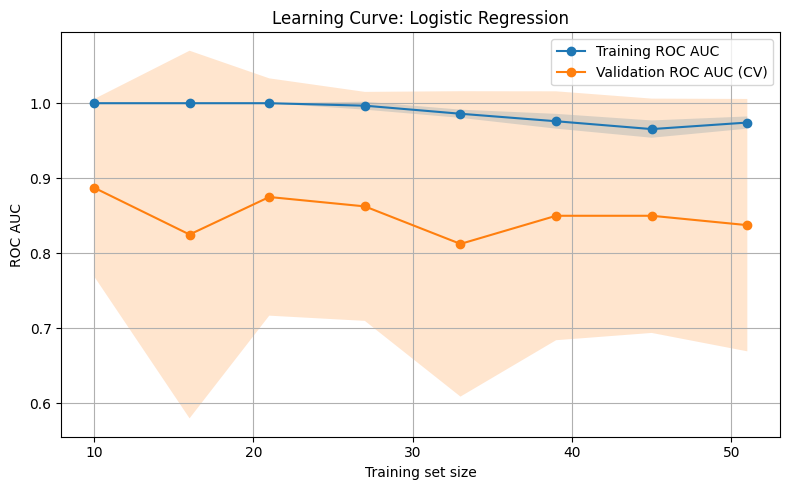

Final training ROC AUC:   0.9742
Final validation ROC AUC: 0.8375
Gap (overfitting signal): 0.1367


In [14]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    model_lr, X, y,
    cv=skf,
    scoring='roc_auc',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training ROC AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, marker='o', label='Validation ROC AUC (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.title('Learning Curve: Logistic Regression')
plt.xlabel('Training set size')
plt.ylabel('ROC AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f"Final training ROC AUC:   {train_mean[-1]:.4f}")
print(f"Final validation ROC AUC: {val_mean[-1]:.4f}")
print(f"Gap (overfitting signal): {gap:.4f}")


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'LogisticRegression': Pipeline([
        ('prep', preprocessor),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('prep', preprocessor),
        ('dt', DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor),
        ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'GradientBoosting': Pipeline([
        ('prep', preprocessor),
        ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42))
    ])
}

scoring = {
    'accuracy':          'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1':                'f1',
    'roc_auc':           'roc_auc',
    'neg_log_loss':      'neg_log_loss'
}

results_list = []
for name, model in models.items():
    cv_res = cross_validate(model, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    row = {'Model': name}
    for key, vals in cv_res.items():
        if key.startswith('test_'):
            metric = key.replace('test_', '')
            row[f'{metric}_mean'] = vals.mean() * (-1 if metric == 'neg_log_loss' else 1)
            row[f'{metric}_std']  = vals.std()
    results_list.append(row)

comparison_df = pd.DataFrame(results_list).sort_values('roc_auc_mean', ascending=False).reset_index(drop=True)

print("Model Comparison -- 10-Fold CV (sorted by ROC AUC)")
print("=" * 70)
for _, row in comparison_df.iterrows():
    print(f"{row['Model']:<22} | Acc: {row['accuracy_mean']:.3f} | "
          f"F1: {row['f1_mean']:.3f} | ROC AUC: {row['roc_auc_mean']:.3f} +/- {row['roc_auc_std']:.3f}")


Model Comparison -- 10-Fold CV (sorted by ROC AUC)
LogisticRegression     | Acc: 0.783 | F1: 0.703 | ROC AUC: 0.838 +/- 0.168
RandomForest           | Acc: 0.777 | F1: 0.550 | ROC AUC: 0.838 +/- 0.159
GradientBoosting       | Acc: 0.700 | F1: 0.564 | ROC AUC: 0.787 +/- 0.177
DecisionTree           | Acc: 0.730 | F1: 0.603 | ROC AUC: 0.700 +/- 0.227


In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

best_model_name = comparison_df.iloc[0]['Model']
print(f"Best model from comparison: {best_model_name}")
print(f"CV ROC AUC: {comparison_df.iloc[0]['roc_auc_mean']:.4f}")
print("Running GridSearchCV...\n")

tuning_configs = {
    'LogisticRegression': {
        'pipeline': Pipeline([
            ('prep', preprocessor),
            ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
        ]),
        'param_grid': {
            'lr__C':       [0.01, 0.1, 1.0, 10.0],
            'lr__penalty': ['l2']
        }
    },
    'DecisionTree': {
        'pipeline': Pipeline([
            ('prep', preprocessor),
            ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42))
        ]),
        'param_grid': {
            'dt__max_depth':        [2, 3, 4, 5, 6],
            'dt__min_samples_leaf': [1, 2, 3]
        }
    },
    'RandomForest': {
        'pipeline': Pipeline([
            ('prep', preprocessor),
            ('rf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
        ]),
        'param_grid': {
            'rf__n_estimators':     [50, 100, 200],
            'rf__max_depth':        [2, 3, 4, 5],
            'rf__min_samples_leaf': [1, 2, 3]
        }
    },
    'GradientBoosting': {
        'pipeline': Pipeline([
            ('prep', preprocessor),
            ('gb', GradientBoostingClassifier(random_state=42))
        ]),
        'param_grid': {
            'gb__n_estimators':  [50, 100, 200],
            'gb__max_depth':     [2, 3, 4],
            'gb__learning_rate': [0.05, 0.1, 0.2]
        }
    }
}

config = tuning_configs[best_model_name]

grid_search = GridSearchCV(
    estimator=config['pipeline'],
    param_grid=config['param_grid'],
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X, y)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV ROC AUC: {grid_search.best_score_:.4f}")

best_pipeline = grid_search.best_estimator_


Best model from comparison: LogisticRegression
CV ROC AUC: 0.8375
Running GridSearchCV...

Best parameters: {'lr__C': 0.1, 'lr__penalty': 'l2'}
Best CV ROC AUC: 0.9000


## Section 4 - Evaluation & Selection

**Primary evaluation method: 10-fold cross-validation on all 57 donors.**
With n=57, a held-out test set of ~12 samples (including only ~5 churned donors) produces metrics with confidence intervals so wide they are not meaningful. Cross-validation uses all available data and provides more reliable estimates.

In [17]:
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import cross_val_predict

# cross_val_predict generates out-of-fold predictions for every sample
# This gives a confusion matrix across all 57 donors without a separate test set
y_pred  = cross_val_predict(best_pipeline, X, y, cv=skf, method='predict')
y_proba = cross_val_predict(best_pipeline, X, y, cv=skf, method='predict_proba')[:, 1]

print("Classification Report (10-fold cross-validated, all 57 donors):")
print(classification_report(y, y_pred, target_names=['Retained', 'Churned']))


Classification Report (10-fold cross-validated, all 57 donors):
              precision    recall  f1-score   support

    Retained       0.86      0.84      0.85        38
     Churned       0.70      0.74      0.72        19

    accuracy                           0.81        57
   macro avg       0.78      0.79      0.79        57
weighted avg       0.81      0.81      0.81        57



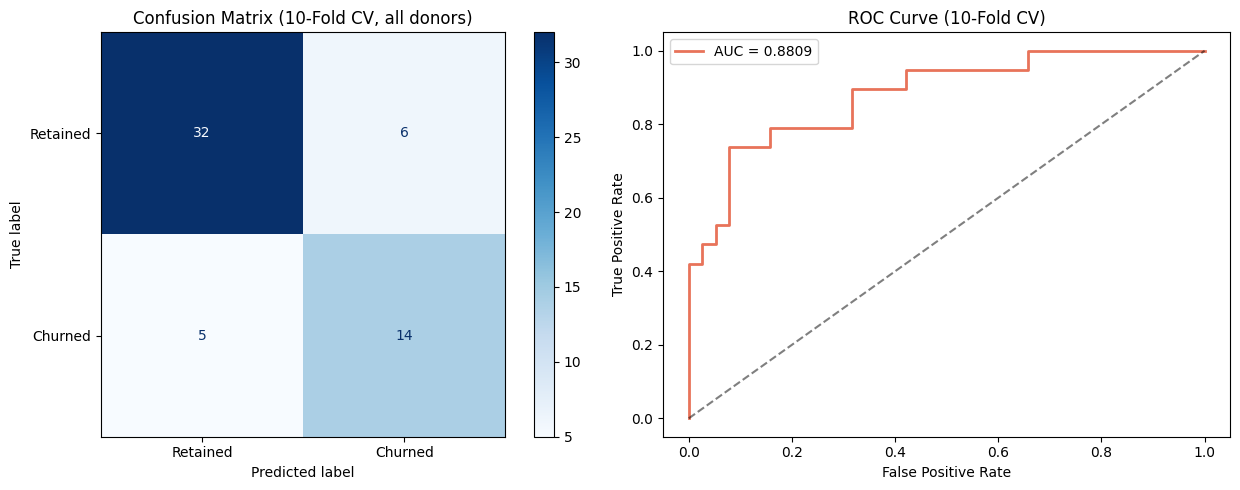

ROC-AUC (CV): 0.8809


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix from CV predictions across all donors
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=['Retained', 'Churned'],
    ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion Matrix (10-Fold CV, all donors)')

# ROC curve from CV probability scores
auc = roc_auc_score(y, y_proba)
fpr, tpr, _ = roc_curve(y, y_proba)
axes[1].plot(fpr, tpr, color='#E8735A', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (10-Fold CV)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"ROC-AUC (CV): {auc:.4f}")


### Limitations

**Sample size is the primary constraint.** With 57 donors, no evaluation method will produce highly reliable performance estimates. Specifically:

- Standard deviations across CV folds are large, meaning performance varies significantly depending on which donors land in which fold
- Feature importance rankings may shift with more data
- The model should be treated as a **directional tool** — the probability score it produces (0 to 1) is useful for ranking donors by risk, even if the exact calibration is imperfect

**What improves over time:** As Harbor of Hope grows its donor base, rerunning this pipeline with more records will produce progressively more stable and trustworthy results. The pipeline is built to be re-run — the methodology does not need to change, only the data.

### Business Interpretation

**False Negative (missed churn):** Predicts retained, donor actually lapses. No outreach is sent. The organization loses a donor who could have been saved. **This is the most costly error** -- lapsed donors are expensive to reacquire.

**False Positive (unnecessary outreach):** Flags a loyal donor as at-risk. Staff sends unnecessary outreach. The cost is low -- some wasted effort and perhaps a slightly annoyed donor.

**Implication:** Recall matters more than precision for this use case. We would rather over-flag and send extra outreach than silently miss a donor about to lapse. If outreach capacity is limited, use the predicted probability score (not just the binary label) to triage -- a donor at 0.9 probability should be contacted before one at 0.55.


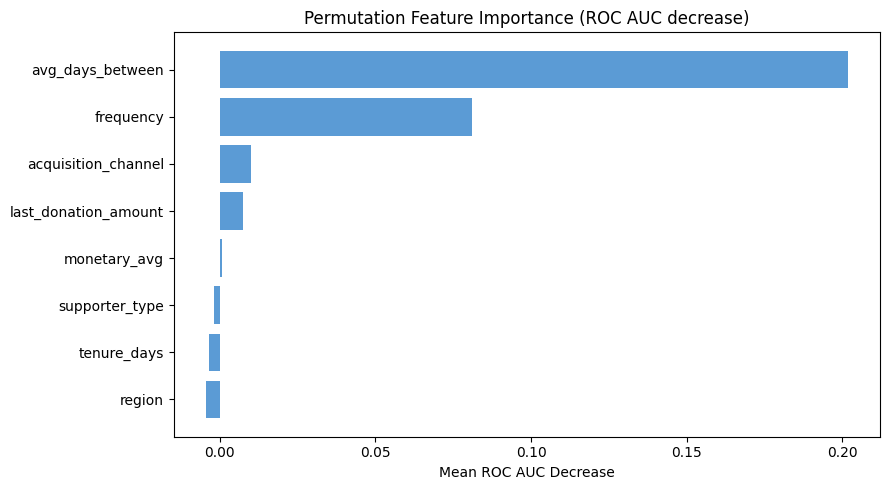

In [19]:
from sklearn.inspection import permutation_importance

# Fit on all data for final importance estimate
best_pipeline.fit(X, y)

perm = permutation_importance(
    best_pipeline, X, y,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

imp_df = pd.DataFrame({
    'Feature':    list(X.columns),
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='#5B9BD5')
ax.set_title('Permutation Feature Importance (ROC AUC decrease)')
ax.set_xlabel('Mean ROC AUC Decrease')
plt.tight_layout()
plt.show()


## Section 5 - Deployment & Integration

**Deployment Architecture:** Pre-computed predictions written to PostgreSQL.

This model is deployed as an offline batch pipeline. The production workflow is:

1. **ETL:** `jobs/etl_donor_churn.py` reads supporters and donations from PostgreSQL, engineers features, and writes the `ml_donor_churn_features` table.
2. **Train:** `jobs/train_donor_churn.py` trains the sklearn Pipeline, saves the model as `artifacts/donor_churn.sav` along with `metadata.json` and `metrics.json`.
3. **Inference:** `jobs/run_inference_donor_churn.py` loads the trained model, predicts churn probability for all supporters, and writes results to the `donor_churn_predictions` table in PostgreSQL.

The .NET backend queries `donor_churn_predictions` via EF Core. The frontend surfaces churn risk badges and probability scores via `GET /api/predictions/churn`, giving the fundraising team a ranked list of at-risk donors to triage.

**Model type:** Predictive binary classification -- identify at-risk donors before they lapse so staff can intervene.

In [20]:
import joblib

# Final model fit on all available data
best_pipeline.fit(X, y)

model_path = '../artifacts/donor_churn.sav'
joblib.dump(best_pipeline, model_path)
print(f"Model saved to: {model_path}")
print(f"\nInput features: {numeric_features + categorical_features}")
print("\nProduction scripts:")
print("  ETL:       jobs/etl_donor_churn.py")
print("  Train:     jobs/train_donor_churn.py")
print("  Inference: jobs/run_inference_donor_churn.py")
print("\nPredictions written to PostgreSQL table: donor_churn_predictions")


Model saved to: ../artifacts/donor_churn.sav

Input features: ['frequency', 'monetary_avg', 'last_donation_amount', 'tenure_days', 'avg_days_between', 'supporter_type', 'acquisition_channel', 'region']

Production scripts:
  ETL:       jobs/etl_donor_churn.py
  Train:     jobs/train_donor_churn.py
  Inference: jobs/run_inference_donor_churn.py

Predictions written to PostgreSQL table: donor_churn_predictions


In [21]:
# Example: score a single donor
sample = pd.DataFrame([{
    'frequency':             5,
    'monetary_avg':          500.0,
    'last_donation_amount':  250.0,
    'tenure_days':           730,
    'avg_days_between':      150.0,
    'supporter_type':        'MonetaryDonor',
    'acquisition_channel':   'SocialMedia',
    'region':                'Luzon'
}])

pred  = best_pipeline.predict(sample)[0]
proba = best_pipeline.predict_proba(sample)[0]

print(f"Prediction:  {'Churned' if pred == 1 else 'Retained'}")
print(f"Probability: Retained={proba[0]:.4f}, Churned={proba[1]:.4f}")


Prediction:  Retained
Probability: Retained=0.7233, Churned=0.2767
